In [1]:
import pandas as pd
import boto3

### ALSFRS-R

In [2]:
s3 = boto3.client('s3')
s3.download_file(
    'eals-rapa-demographics-bucket', 
    'RAPA EAP ALSFRS Data.csv',
    'data/RAPA EAP ALSFRS Data.csv'
)

In [3]:
df_alsfrsr = pd.read_csv('data/RAPA EAP ALSFRS Data.csv', sep=';')
df_alsfrsr.eals_id.nunique(), df_alsfrsr.shape[0]

(17, 142)

### ROADS

In [4]:
s3 = boto3.client('s3')
s3.download_file('eals-rapa-demographics-bucket', 'RAPA EAP ROADS Data.csv', 'data/RAPA EAP ROADS Data.csv')

In [5]:
df = pd.read_csv('data/RAPA EAP ROADS Data.csv', sep=';')
df.eals_id.nunique(), df.shape[0]

(17, 141)

### Demographics

In [6]:
s3 = boto3.client('s3')
s3.download_file('eals-rapa-demographics-bucket', 'RAPA EAP Demographics Data.csv', 'data/RAPA EAP Demographics Data.csv')

In [7]:
df = pd.read_csv('data/RAPA EAP Demographics Data.csv', sep=';')
df.eals_id.nunique(), df.shape[0]

(22, 1374)

### Zephyr X

In [8]:
!aws s3 sync s3://eals-rapa-zephyrx-bucket/tests/ data/zephyrx/tests/

In [9]:
!aws s3 ls eals-rapa-zephyrx-bucket/tests/ --recursive | wc -l # confirmamos que en bucket hay misma cantidad

283


In [10]:
import os
files_tests = os.listdir('data/zephyrx/tests/')
len(files_tests)

283

In [11]:
import json

# Load tests
tests = []
for file in files_tests:
    with open('data/zephyrx/tests/' + file) as f:
        data = json.load(f)
    tests.append(data)
df_zephyrx = pd.DataFrame(tests)

df_zephyrx.patientID.nunique(), df_zephyrx.shape[0]

(13, 283)

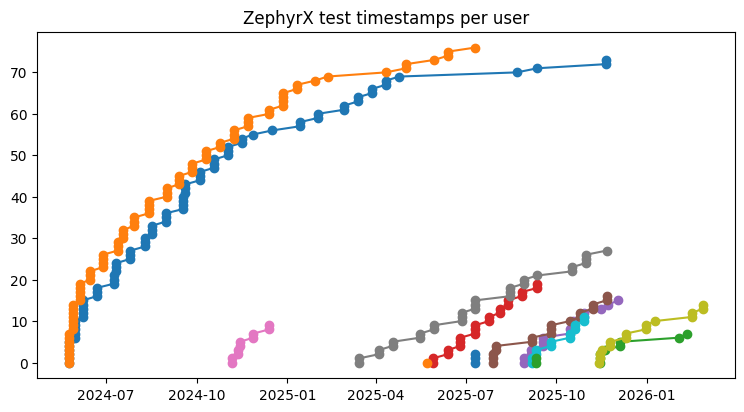

In [12]:
uids = df_zephyrx.patientID.unique()

from matplotlib import pyplot as plt
plt.figure(figsize=(12*.75,6*.75))
plt.title('ZephyrX test timestamps per user')
for uid in uids:
    df_user = df_zephyrx[df_zephyrx.patientID == uid]
    to_plot = pd.to_datetime(df_user.created, utc=True).sort_values().reset_index(drop=True)
    plt.plot(to_plot,range(len(to_plot)), marker='o', label=uid)

In [13]:
df_zephyrx.spirometerID.value_counts()

spirometerID
SM-005-Z135983    77
SM-005-Z135984    74
SM-005-Z134051    28
SM-005-Z127951    20
SM-005-Z134049    17
SM-005-Z127970    16
SM-005-Z127964    15
SM-005-Z134068    12
SM-005-Z127959    10
SM-005-Z134052     8
SM-005-Z127956     3
SM-005-Z136315     2
SM-005-Z134047     1
Name: count, dtype: int64

In [14]:
df_zephyrx.studyID.value_counts()

studyID
a07848cb-83b1-48ef-a314-ae5b5e5d448b    77
cee20458-8561-4496-932c-6855e6299641    74
7ed30a17-32ec-4945-8598-1f08051e2e8d    28
c2cc4d94-b103-407a-86f4-fb707b385a82    20
8adba8d9-edd8-434c-b794-b2077322fc13    17
9485abe1-c1b5-4d27-8540-12b0f9807782    16
b96c8a5b-8902-423a-8ced-18f6b01e9885    15
75f732c6-c4b2-46df-8757-868b847aa3b0    12
ca0d5d71-4c18-45e7-8c04-81feb7695e24    10
f8823c7d-30bb-47f6-855c-e71b1962f1af     8
1b0b349e-301f-46a4-a137-1fed70ca678d     3
9c09639d-2956-4110-8f63-7aada0e25173     2
a1568d21-c1f4-447c-8a4d-3565003d4773     1
Name: count, dtype: int64

In [15]:
all_efforts = []
for efforts in df_zephyrx['efforts']:
    all_efforts.extend(efforts)
pd.DataFrame(all_efforts).patientID.value_counts()

patientID
49f02607-d986-4faa-8c65-7671f1de3211    214
c0b564f5-78ff-4603-a0f5-4b2c09d472ed    191
9a3777ca-6d0c-4b50-bd9b-641ef60ee56c     56
b2ff67ac-ba92-439a-a5c1-268cb008d6de     55
faea75b6-76b4-4a49-91ea-145f76e836dd     45
957c72db-ba7b-4319-a123-a53f501d7ab2     44
3dd6ef6e-4f96-4afd-9212-022d143d9bfb     35
976d1894-1727-4204-8446-02212a5d01d2     29
bcec013f-7307-41a2-b620-5aab64864baa     25
a3b89522-3c31-4ec9-89fb-049810995e55     13
6e4eb375-b33f-464f-b0a3-ccb3aed558fa      9
6af71391-fd3c-4cf3-b2a4-1bbffcee2d68      5
9a58922a-9d74-418a-90ac-df5a35e75b66      2
Name: count, dtype: int64

In [16]:
import pandas as pd
pd.set_option('display.max_columns', None)
df_zephyrx.head()

,patientID,seriesID,spirometerID,coachedSessionID,bestEffortID,externalSessionID,created,timezoneName,deviceModel,appVersion,firmwareVersion,name,studyID,birth,genderAtBirth,ethnicity,heightInches,weightLbs,patientPosition,rejected,quality,originalQuality,acceptable,repeatable,notes,pftType,vc,vcPred,vcPercPred,vcLln,vcZ,vcLetterGrade,vcVariability,flowVolumeCurve,efforts,fvc,fvcPred,fvcPercPred,fvcLln,fvcZ,fvcLetterGrade,fvcVariability,fev1,fev1Pred,fev1PercPred,fev1Lln,fev1Z,fev1LetterGrade,fev1Variability,fev1Fvc,fev1FvcPred,fev1FvcPercPred,fev1FvcLln,fev1FvcZ,fev6,fivc,pef,bev,fet,pif,fef2575,fef2575Pred,fef2575PercPred,fef2575Lln,fef2575Z,bestEffortID_2019,acceptability_2019,fvcRepeatable_2019,fev1Repeatable_2019,flowVolumeCurve_2019,fvc_2019,fvcPred_2019,fvcPercPred_2019,fvcLln_2019,fvcZ_2019,fvcLetterGrade_2019,fvcVariability_2019,fev1_2019,fev1Pred_2019,fev1PercPred_2019,fev1Lln_2019,fev1Z_2019,fev1LetterGrade_2019,fev1Variability_2019,fev1Fvc_2019,fev1FvcPred_2019,fev1FvcPercPred_2019,fev1FvcLln_2019,fev1FvcZ_2019,fev6_2019,fivc_2019,pef_2019,bev_2019,fet_2019,pif_2019,fef2575_2019,fef2575Pred_2019,fef2575PercPred_2019,fef2575Lln_2019,fef2575Z_2019
0,49f02607-d986-4faa-8c65-7671f1de3211,40235bd9-c31d-4fa0-9e4f-2298a1a951a4,SM-005-Z135984,65f54ebd-4fb4-4355-bd15-2c2d48600706,956c6159-dbdb-4c38-8034-94da99279df9,,2024-06-07T11:35:28.048-07:00,PDT,Xiaomi 22101320G,1.16.0,4.5,,cee20458-8561-4496-932c-6855e6299641,1956-04-15,FEMALE,NORTH_EAST_ASIAN,69.00,146.00,na,False,GoodBlow,GoodBlow,True,True,,svc,1.53,3.36,0.46,2.61,-4.2,A,0.05,"{'points': [[0, 0.31], [0, 0.31], [0.1, 0.27],...",[{'patientID': '49f02607-d986-4faa-8c65-7671f1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,c0b564f5-78ff-4603-a0f5-4b2c09d472ed,d1971484-4950-478a-b4ca-454b7e10b41f,SM-005-Z135983,153feb0b-c8ba-4a8d-a41c-046f67510706,edc4351e-e893-4761-a738-98abc7f0e000,,2024-05-24T08:57:43.870-07:00,PDT,Xiaomi 22101320G,1.16.0,4.5,,a07848cb-83b1-48ef-a314-ae5b5e5d448b,1966-03-06,MALE,CAUCASIAN,71.00,185.00,na,True,GoodBlow,GoodBlow,True,False,,fvc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'points': [[0, 0, 0], [0.517357, 0, 0.1], [1....",[{'patientID': 'c0b564f5-78ff-4603-a0f5-4b2c09...,0.00,0.00,0.00,0.00,0.00,E,0.00,0.00,0.00,0.00,0.00,0.00,E,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,,NotAcceptable,False,False,"{'points': [[0, 0, 0], [0.0011970999999999777,...",0.00,0.00,0.00,0.00,0.00,F,0.00,0.00,0.00,0.00,0.00,0.00,F,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,a3b89522-3c31-4ec9-89fb-049810995e55,29b51a70-f102-41fc-9a7e-658699ca8de0,SM-005-Z134052,04fa4f17-c5b6-42b2-b844-711bedca7285,483fded2-e997-4840-a91a-dec7c679180e,,2025-12-04T12:26:15.476-05:00,EST,"iPhone15,3",1.19.0,4.5,,f8823c7d-30bb-47f6-855c-e71b1962f1af,1957-07-20,FEMALE,CAUCASIAN,64.00,183.00,na,False,GoodBlow,GoodBlow,True,False,,fvc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'points': [[0, 0, 0], [0.14987069999999994, 0...",[{'patientID': 'a3b89522-3c31-4ec9-89fb-049810...,0.29,2.90,0.10,2.13,-6.24,E,0.00,0.17,2.26,0.08,1.65,-5.19,E,0.00,0.59,0.78,0.75,0.65,-2.37,0.29,0.00,0.44,0.00,2.19,0.00,0.10,1.93,0.05,0.91,-4.16,483fded2-e997-4840-a91a-dec7c679180e,Usable,False,False,"{'points': [[0, 0, 0], [0.14987069999999994, 0...",0.29,2.90,0.10,2.13,-6.24,U,0.00,0.17,2.26,0.08,1.65,-5.19,E,0.00,0.59,0.78,0.75,0.65,-2.37,0.29,0.00,0.44,0.00,2.19,0.00,0.10,1.93,0.05,0.91,-4.16
3,c0b564f5-78ff-4603-a0f5-4b2c09d472ed,26ddaf34-f5c5-48dd-a00c-cef3beb87611,SM-005-Z135983,23c728b0-c1af-454c-90b4-54f176520706,2c229f42-15a8-497f-a01c-204c935ea645,,2024-06-14T13:03:35.316-07:00,PDT,Xiaomi 22101320G,1.16.0,4.5,,a07848cb-83b1-48ef-a314-ae5b5e5d448b,1966-03-06,MALE,CAUCASIAN,71.00,185.00,na,False,GoodBlow,GoodBlow,True,True,,fvc,NaN

### Aural

In [17]:
!aws s3 sync s3://eals-rapa-aural-bucket/ data/aural/

In [18]:
first_level = os.listdir('data/aural/')
print('Number of users: ', len(first_level))

df_wavs = pd.DataFrame()
all_second_level = []
for fl in first_level:
    second_level = os.listdir(f'data/aural/{fl}/')

    for sl in second_level:
        files = os.listdir(f'data/aural/{fl}/{sl}')
        has_all_files = True
        for req_file in [f'{sl}_meta.json', f'{sl}_metrics.json', f'{sl}_steps_meta.json']:
            if req_file not in files:
                has_all_files = False
                break
        if has_all_files:
            all_second_level.append(sl)
        else:
            print(f'Missing files for session {sl} of user {fl}')
        with open(f'data/aural/{fl}/{sl}/{sl}_meta.json') as f:
            data = json.load(f)
        df_session = pd.DataFrame([data])
        df_wavs = pd.concat([df_wavs, df_session], ignore_index=True)
        
print('Number of users also in ALSFRS-R data: ', df_wavs.query('participantId in @df_alsfrsr.eals_id.unique()').participantId.nunique())
print('Number of all sessions: ', len(all_second_level))

Number of users:  11
Number of users also in ALSFRS-R data:  9
Number of all sessions:  156


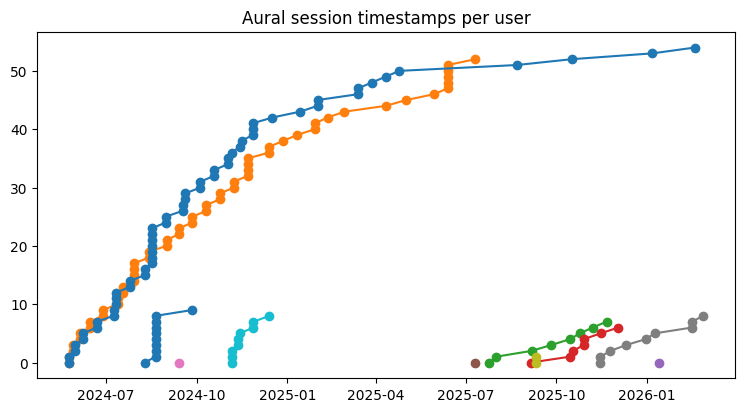

In [19]:
uids = df_wavs.participantId.unique()

from matplotlib import pyplot as plt
plt.figure(figsize=(12*.75,6*.75))
plt.title('Aural session timestamps per user')
for uid in uids:
    df_user = df_wavs[df_wavs.participantId == uid]
    to_plot = pd.to_datetime(df_user.startTime, utc=True).sort_values().reset_index(drop=True)
    plt.plot(to_plot,range(len(to_plot)), marker='o', label=uid)

In [20]:
req_file = [f'{sl}_meta.json', f'{sl}_metrics.json', f'{sl}_steps_meta.json']
print('User id: ', fl)
print('Session id: ', sl)
with open(f'data/aural/{fl}/{sl}/{req_file[0]}') as f:
    data = json.load(f)
# data['aggregates']#['stepsUsed']
# pd.DataFrame(data['aggregates'])
# pd.DataFrame(data)
data

User id:  cee20458-8561-4496-932c-6855e6299641
Session id:  20241004-112804-A97146


{'appName': 'EverythingALS',
 'appVersion': '1.0.1',
 'startTime': '2024-10-04T11:28:09-07:00',
 'language': 'en-us',
 'scriptLanguage': 'en-us',
 'totalSteps': 18,
 'appPlatform': 'Android 14',
 'sessionScriptId': 'everythingals-radcliff.2b-v2',
 'appDevice': 'Xiaomi 22101320G [redwood]',
 'sdkVersion': '1.9.0',
 'sessionTag': 'my tag',
 'sessionId': '20241004-112804-A97146',
 'participantId': 'cee20458-8561-4496-932c-6855e6299641',
 'inClinic': True,
 'uuid': '5473c2eb-42d7-4c23-aaab-e5ecd810f63e',
 'sessionCount': 32}